# Week 2 — Exploratory Data Analysis: NextGenLearners Applicant Insights
**Intern:** Maria
**Internship:** NextGen Learners — Data Science Internship
**Task:** Explore the cleaned applicant dataset from Week 1, ask specific questions, and answer each with an aggregation, a labeled chart, and a plain-English takeaway.

## Step 1: Setup
Loading the cleaned file from Week 1. `Application Date` is re-parsed as a real datetime, since CSVs only store plain text and the datetime type doesn't survive a save/reload on its own.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('applicants_cleaned.csv', dtype={'Phone': str}, parse_dates=['Application Date'])

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Applicant Name    83 non-null     str           
 1   Email             83 non-null     str           
 2   Phone             83 non-null     str           
 3   Domain Applied    83 non-null     str           
 4   University        83 non-null     str           
 5   Application Date  77 non-null     datetime64[us]
 6   Status            83 non-null     str           
dtypes: datetime64[us](1), str(6)
memory usage: 4.7 KB


In [3]:
df.head()

,Applicant Name,Email,Phone,Domain Applied,University,Application Date,Status
0,Martin Ross,sheila14@example.org,03940196556,Graphic Design,NED University,2026-04-06,Selected
1,Michael Valencia,keyemily@example.com,03902787429,Digital Marketing,IBA Karachi,2026-05-15,Selected
2,Carmen Rose,ibrandt@example.net,03346578713,Web Development,Shah Abdul Latif University,2026-04-19,Selected
3,Eric Ortiz,jterry@example.org,03366299468,Graphic Design,Shah Abdul Latif University,2026-07-02,Rejected
4,Jennifer Brown,not_provided@example.com,03480184514,Graphic Design,Shah Abdul Latif University,2026-05-15,Selected


**Sanity check:** 83 rows, no missing values in the critical fields, and `Application Date` shows as `datetime64` — confirms the Week 1 cleaning carried over correctly.

## Step 3: Which Domain Received the Most Applications?
**Question:** Which of the 5 internship domains is most popular with applicants?

In [4]:
domain_counts = df['Domain Applied'].value_counts()
domain_counts

Domain Applied
App Development      21
Data Analytics       21
Digital Marketing    15
Graphic Design       14
Web Development      12
Name: count, dtype: int64

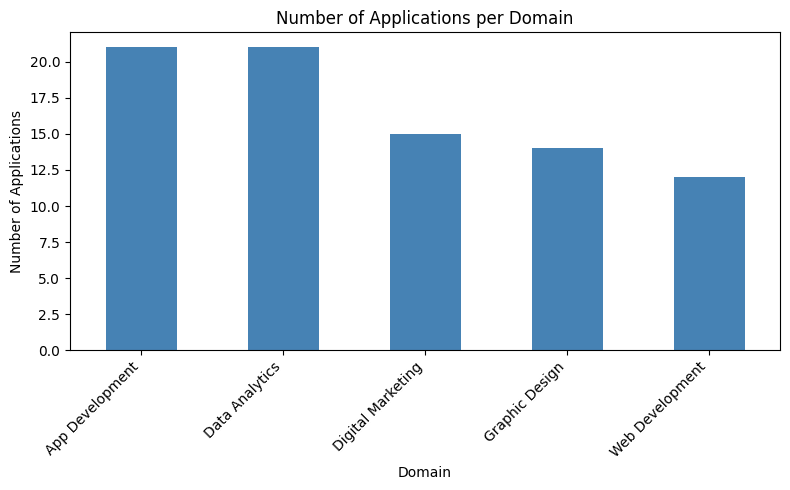

In [5]:
plt.figure(figsize=(8,5))
domain_counts.plot(kind='bar', color='steelblue')
plt.title('Number of Applications per Domain')
plt.xlabel('Domain')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Takeaway:** App Development and Data Analytics are tied for the most applications (21 each), while Web Development received the fewest (12) — under 60% of the top domains' volume.

## Step 4: How Did Applications Trend Over Time?
**Question:** Is application volume steady over time, or concentrated in a particular period?

In [6]:
df['Application Month'] = df['Application Date'].dt.to_period('M')
monthly_trend = df.groupby('Application Month').size()
monthly_trend

Application Month
2026-01     4
2026-02     1
2026-03     4
2026-04    19
2026-05    12
2026-06    16
2026-07    13
2026-08     1
2026-09     2
2026-11     1
2026-12     4
Freq: M, dtype: int64

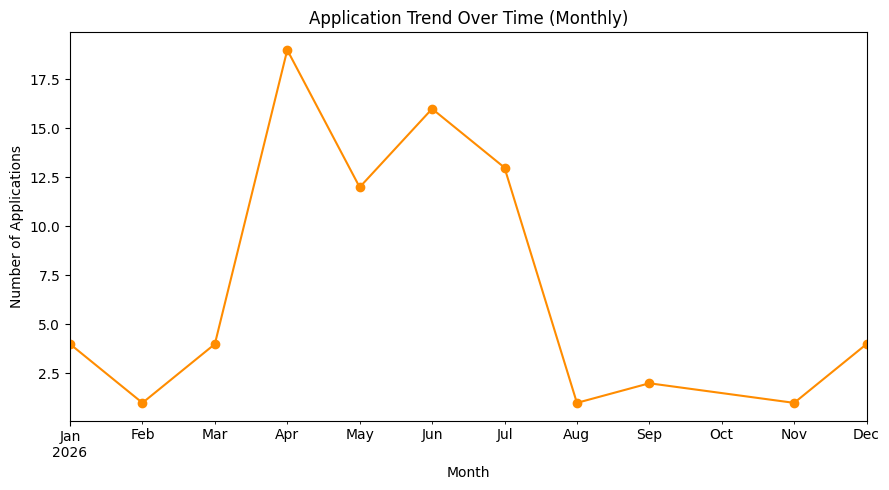

In [7]:
plt.figure(figsize=(9,5))
monthly_trend.plot(kind='line', marker='o', color='darkorange')
plt.title('Application Trend Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.tight_layout()
plt.show()

**Takeaway:** Applications ramped up sharply in April 2026 (19) and stayed strong through July, then dropped off sharply from August onward — suggesting outreach and marketing activity was concentrated in the first half of the year.

## Step 5: What's the Acceptance Rate — Overall and Per Domain?
**Question:** How do applications break down by status, and does acceptance rate vary meaningfully by domain (not just raw counts)?

In [8]:
status_counts = df['Status'].value_counts()
status_counts

Status
Selected        30
Under Review    27
Rejected        26
Name: count, dtype: int64

In [9]:
status_by_domain = pd.pivot_table(
    df,
    index='Domain Applied',
    columns='Status',
    values='Applicant Name',
    aggfunc='count',
    fill_value=0
)
status_by_domain

Status,Rejected,Selected,Under Review
Domain Applied,,,
App Development,8,6,7
Data Analytics,10,7,4
Digital Marketing,3,7,5
Graphic Design,4,5,5
Web Development,1,5,6


In [10]:
status_by_domain_pct = status_by_domain.div(status_by_domain.sum(axis=1), axis=0) * 100
status_by_domain_pct.round(1)

Status,Rejected,Selected,Under Review
Domain Applied,,,
App Development,38.1,28.6,33.3
Data Analytics,47.6,33.3,19.0
Digital Marketing,20.0,46.7,33.3
Graphic Design,28.6,35.7,35.7
Web Development,8.3,41.7,50.0


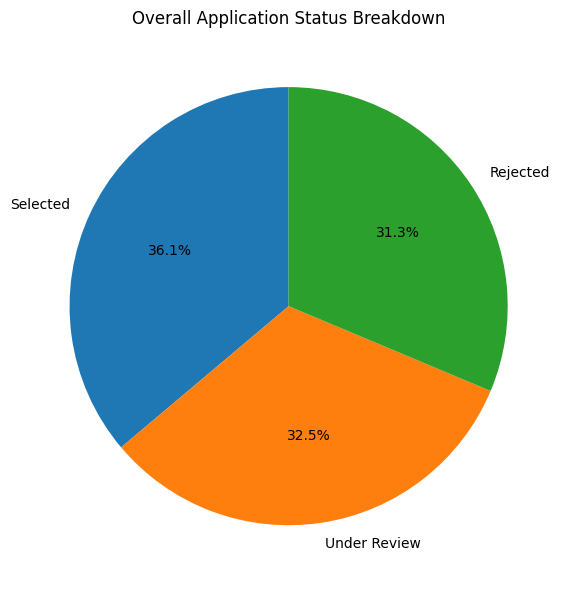

In [11]:
plt.figure(figsize=(6,6))
status_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Overall Application Status Breakdown')
plt.ylabel('')
plt.tight_layout()
plt.show()

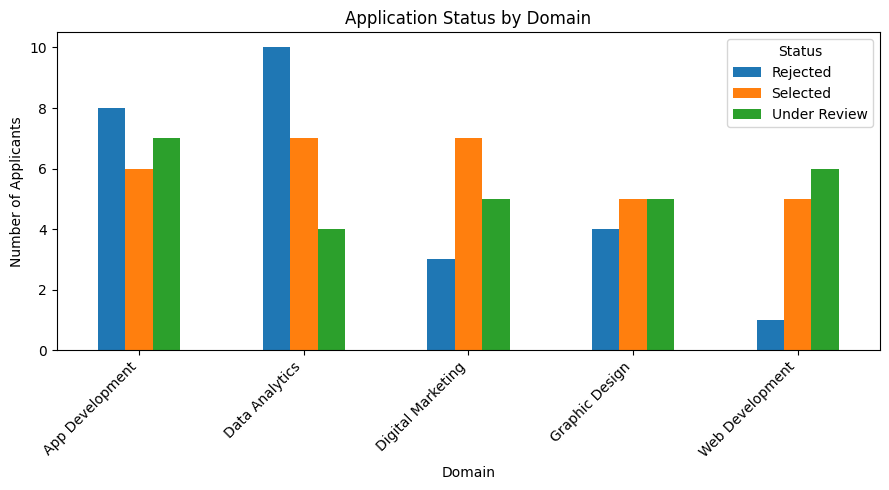

In [12]:
status_by_domain.plot(kind='bar', figsize=(9,5))
plt.title('Application Status by Domain')
plt.xlabel('Domain')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

**Takeaway:** Despite tying for the highest application volume, Data Analytics also has the highest rejection rate (47.6%) — nearly 6x Web Development's (8.3%). Web Development, despite the lowest volume, is rejected far less often and has half its pool still Under Review, suggesting a smaller but stronger-fit applicant pool.

## Step 6: Which Universities Sent the Most Applicants?
**Question:** Are applicants concentrated in a handful of universities, or spread evenly?

Note: `University` includes a `'Not Specified'` placeholder for applicants who left this field blank in the raw data (filled in during Week 1 cleaning). Since that's not a real university, I exclude it here so the ranking only reflects actual institutions.

In [13]:
real_universities = df[df['University'] != 'Not Specified']
top_universities = real_universities['University'].value_counts().head(10)
top_universities

University
NED University                 13
Shah Abdul Latif University    10
LUMS                           10
FAST NUCES                      9
Mehran UET                      8
IBA Karachi                     6
SZABIST                         6
Sindh University                4
Name: count, dtype: int64

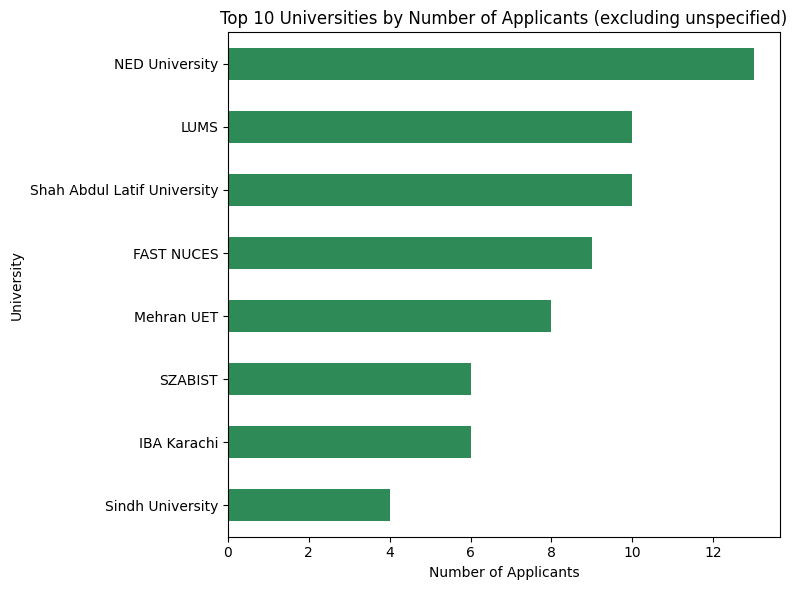

In [14]:
plt.figure(figsize=(8,6))
top_universities.sort_values().plot(kind='barh', color='seagreen')
plt.title('Top 10 Universities by Number of Applicants (excluding unspecified)')
plt.xlabel('Number of Applicants')
plt.ylabel('University')
plt.tight_layout()
plt.show()

**Takeaway:** Among applicants who specified a university, the top 3 — NED University, Shah Abdul Latif University, and LUMS — account for exactly 50% of all applications with a known university, meaning outreach to just a few institutions reaches half the applicant pool.

## Step 7: Bonus Chart — Which Day of the Week Do People Apply?
**Question:** I chose this because application timing can inform when to push outreach or keep the form's server capacity ready — a pattern the other four questions don't cover.

In [15]:
df['Day of Week'] = df['Application Date'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df['Day of Week'].value_counts().reindex(day_order)
day_counts

Day of Week
Monday       13
Tuesday       6
Wednesday    10
Thursday     10
Friday       12
Saturday     16
Sunday       10
Name: count, dtype: int64

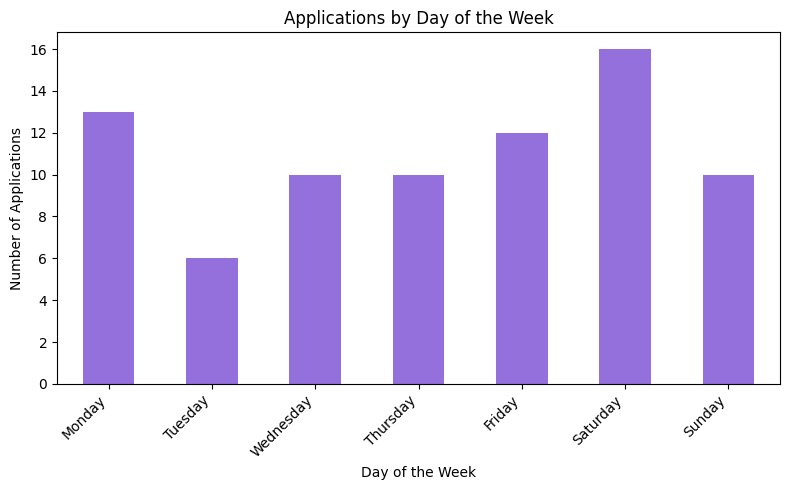

In [16]:
plt.figure(figsize=(8,5))
day_counts.plot(kind='bar', color='mediumpurple')
plt.title('Applications by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Takeaway:** Saturday is the single most common application day (16) — more than any individual weekday — even though weekdays combined still account for more total applications. This suggests a meaningful share of applicants fill out the form during weekend free time.

## Step 8: Key Insights

- **App Development and Data Analytics tie for the most applications (21 each)**, while Web Development trails with only 12 — under 60% of the leading domains' volume.
- **Applications are heavily front-loaded**: volume ramped up in April 2026 and stayed strong through July, then fell off sharply from August onward, pointing to outreach efforts that were concentrated earlier in the year.
- **Raw popularity doesn't equal quality of fit**: Data Analytics has both the highest volume and the highest rejection rate (47.6%), while Web Development — despite the lowest volume — has the lowest rejection rate (8.3%) and half its applicants still Under Review.
- **Outreach is concentrated in a few institutions**: excluding applicants who didn't specify a university, just 3 schools (NED, Shah Abdul Latif University, LUMS) account for half of all applications with a known university — a small number of partnerships could reach a large share of the pipeline.
- **Weekends matter for applicants**: Saturday alone is the single busiest application day, suggesting the application form and any related support should be reliably available outside of standard weekday hours.